# Data Preprocessing Part

In [ ]:
import pandas as pd

# Read raw data from github repo
df=pd.read_csv("https://raw.githubusercontent.com/Alex-Mak-MCW/Deposit_Subcriptions_Predictions_Project/main/Data/input.csv", sep=";")

print(df.shape) # returned (45211, 17), success

(45211, 17)


In [ ]:
# Data Cleaning: handled

# identify null data
print("Number of null values in the dataset:\n{0}".format(df.isnull().sum())) # There are no null values

# identify duplciate data
print("\nNumber of duplicate data in the dataset:\n{0}".format(df.duplicated().sum())) # There are no duplicate values

Number of null values in the dataset:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Number of duplicate data in the dataset:
0


In [ ]:
# Data Transformation:
from sklearn.preprocessing import LabelEncoder

data=df.copy()

# 1. Encode binary variables
# Initialize LabelEncoder for binary encoding
label_encoder = LabelEncoder()

# 1.1 encode binary predictors
data['default']=label_encoder.fit_transform(data['default'])
data['housing']=label_encoder.fit_transform(data['housing'])
data['loan']=label_encoder.fit_transform(data['loan'])

# 1.2 encode binary target variable (y)
data['y']=label_encoder.fit_transform(data['y'])

# 2. encoding categorical data with multiple class (job, marital, education, contact, month, poutcome)

# 2.1 month: since months are just the abbreviations (short forms of the month) --> encode strings to months numerically
data['month']=label_encoder.fit_transform(data['month'])+1

# 2.2 education (unknown exists): map values with setted values where higher educations are mapped with higher values
data['education']=data['education'].map({"unknown": 0, "primary": 1, "secondary": 2, "tertiary": 3})

# 2.3 poutcome (unknown exists): map values with setted values where failure is 0, success is 1, unknown and otheras 0.5
data['poutcome']=data['poutcome'].map({"failure": 0, "success": 1, "unknown": 0.5, "other": 0.5})

# I decided to leave the rest untouched because tree-based methods can handle categorical data pretty well already.
# Hence I did not handle: contact, marital, and job (as of now)


# 3. replace unknown with meaningful value (for contact, education, job)

# 3.1 job, try to categorize retired and student out first based on age, then see what to do

# everyone under 22 are already students, so transform elders
data.loc[data['age'] >66, 'job'] = data.loc[data['age'] >66, 'job'].replace('unknown', 'retired')
# print(data['job'].value_counts()) # 278 unknown values now, 10 unknown ones are removed

# transform adults (6% still do it?)
# print(data['job'].value_counts(normalize=True)) # 278 unknown values now

# 3.2: contact, replace with mode--> cellular
# cellular returns 65%, unknown returns 29%, telephone returns 6%
data['contact']=data['contact'].replace("unknown", "cellular")

# 3.3 education, replace with mode--> 2
# 0: 4%, 1: 15%, 2: 51%, 3: 29%
data['education']=data['education'].replace(0, 2)

# EDA Part

## For examining and understanding the structure, patterns, and relationships within a dataset.

### todo-list:

* provide descriptive statistics (DONE)

* univariate: (DONE)
1. outlier detection through boxplots for continuous data
2. frequency analysis through barplot for discrete data

* outlier and unknown removal--> (DONE)

* multivariate: pairwise scaterplot(predictor vs y) to see trends, correlation analysis to check multicolinarity (heatmaps)

* feature importance model-->

* No standarizations and multicolinearity

* write conclusions

In [ ]:
# Descriptive/ Summary statistics for continuous data

# exclude default, house, loan, poutcome, y (becuase they are categorical variables)
summary=data.describe().drop(['default', 'housing', 'loan', 'poutcome', 'y'], axis=1).style.set_caption('Summary Statistics for Continuous Data').format(precision=2).background_gradient(cmap='Blues')
display(summary)

,age,education,balance,day,month,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,2.14,1362.27,15.81,6.52,258.16,2.76,40.20,0.58
std,10.62,0.65,3044.77,8.32,3.01,257.53,3.10,100.13,2.30
min,18.00,1.00,-8019.00,1.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,2.00,72.00,8.00,4.00,103.00,1.00,-1.00,0.00
50%,39.00,2.00,448.00,16.00,7.00,180.00,2.00,-1.00,0.00
75%,48.00,3.00,1428.00,21.00,9.00,319.00,3.00,-1.00,0.00
max,95.00,3.00,102127.00,31.00,12.00,4918.00,63.00,871.00,275.00


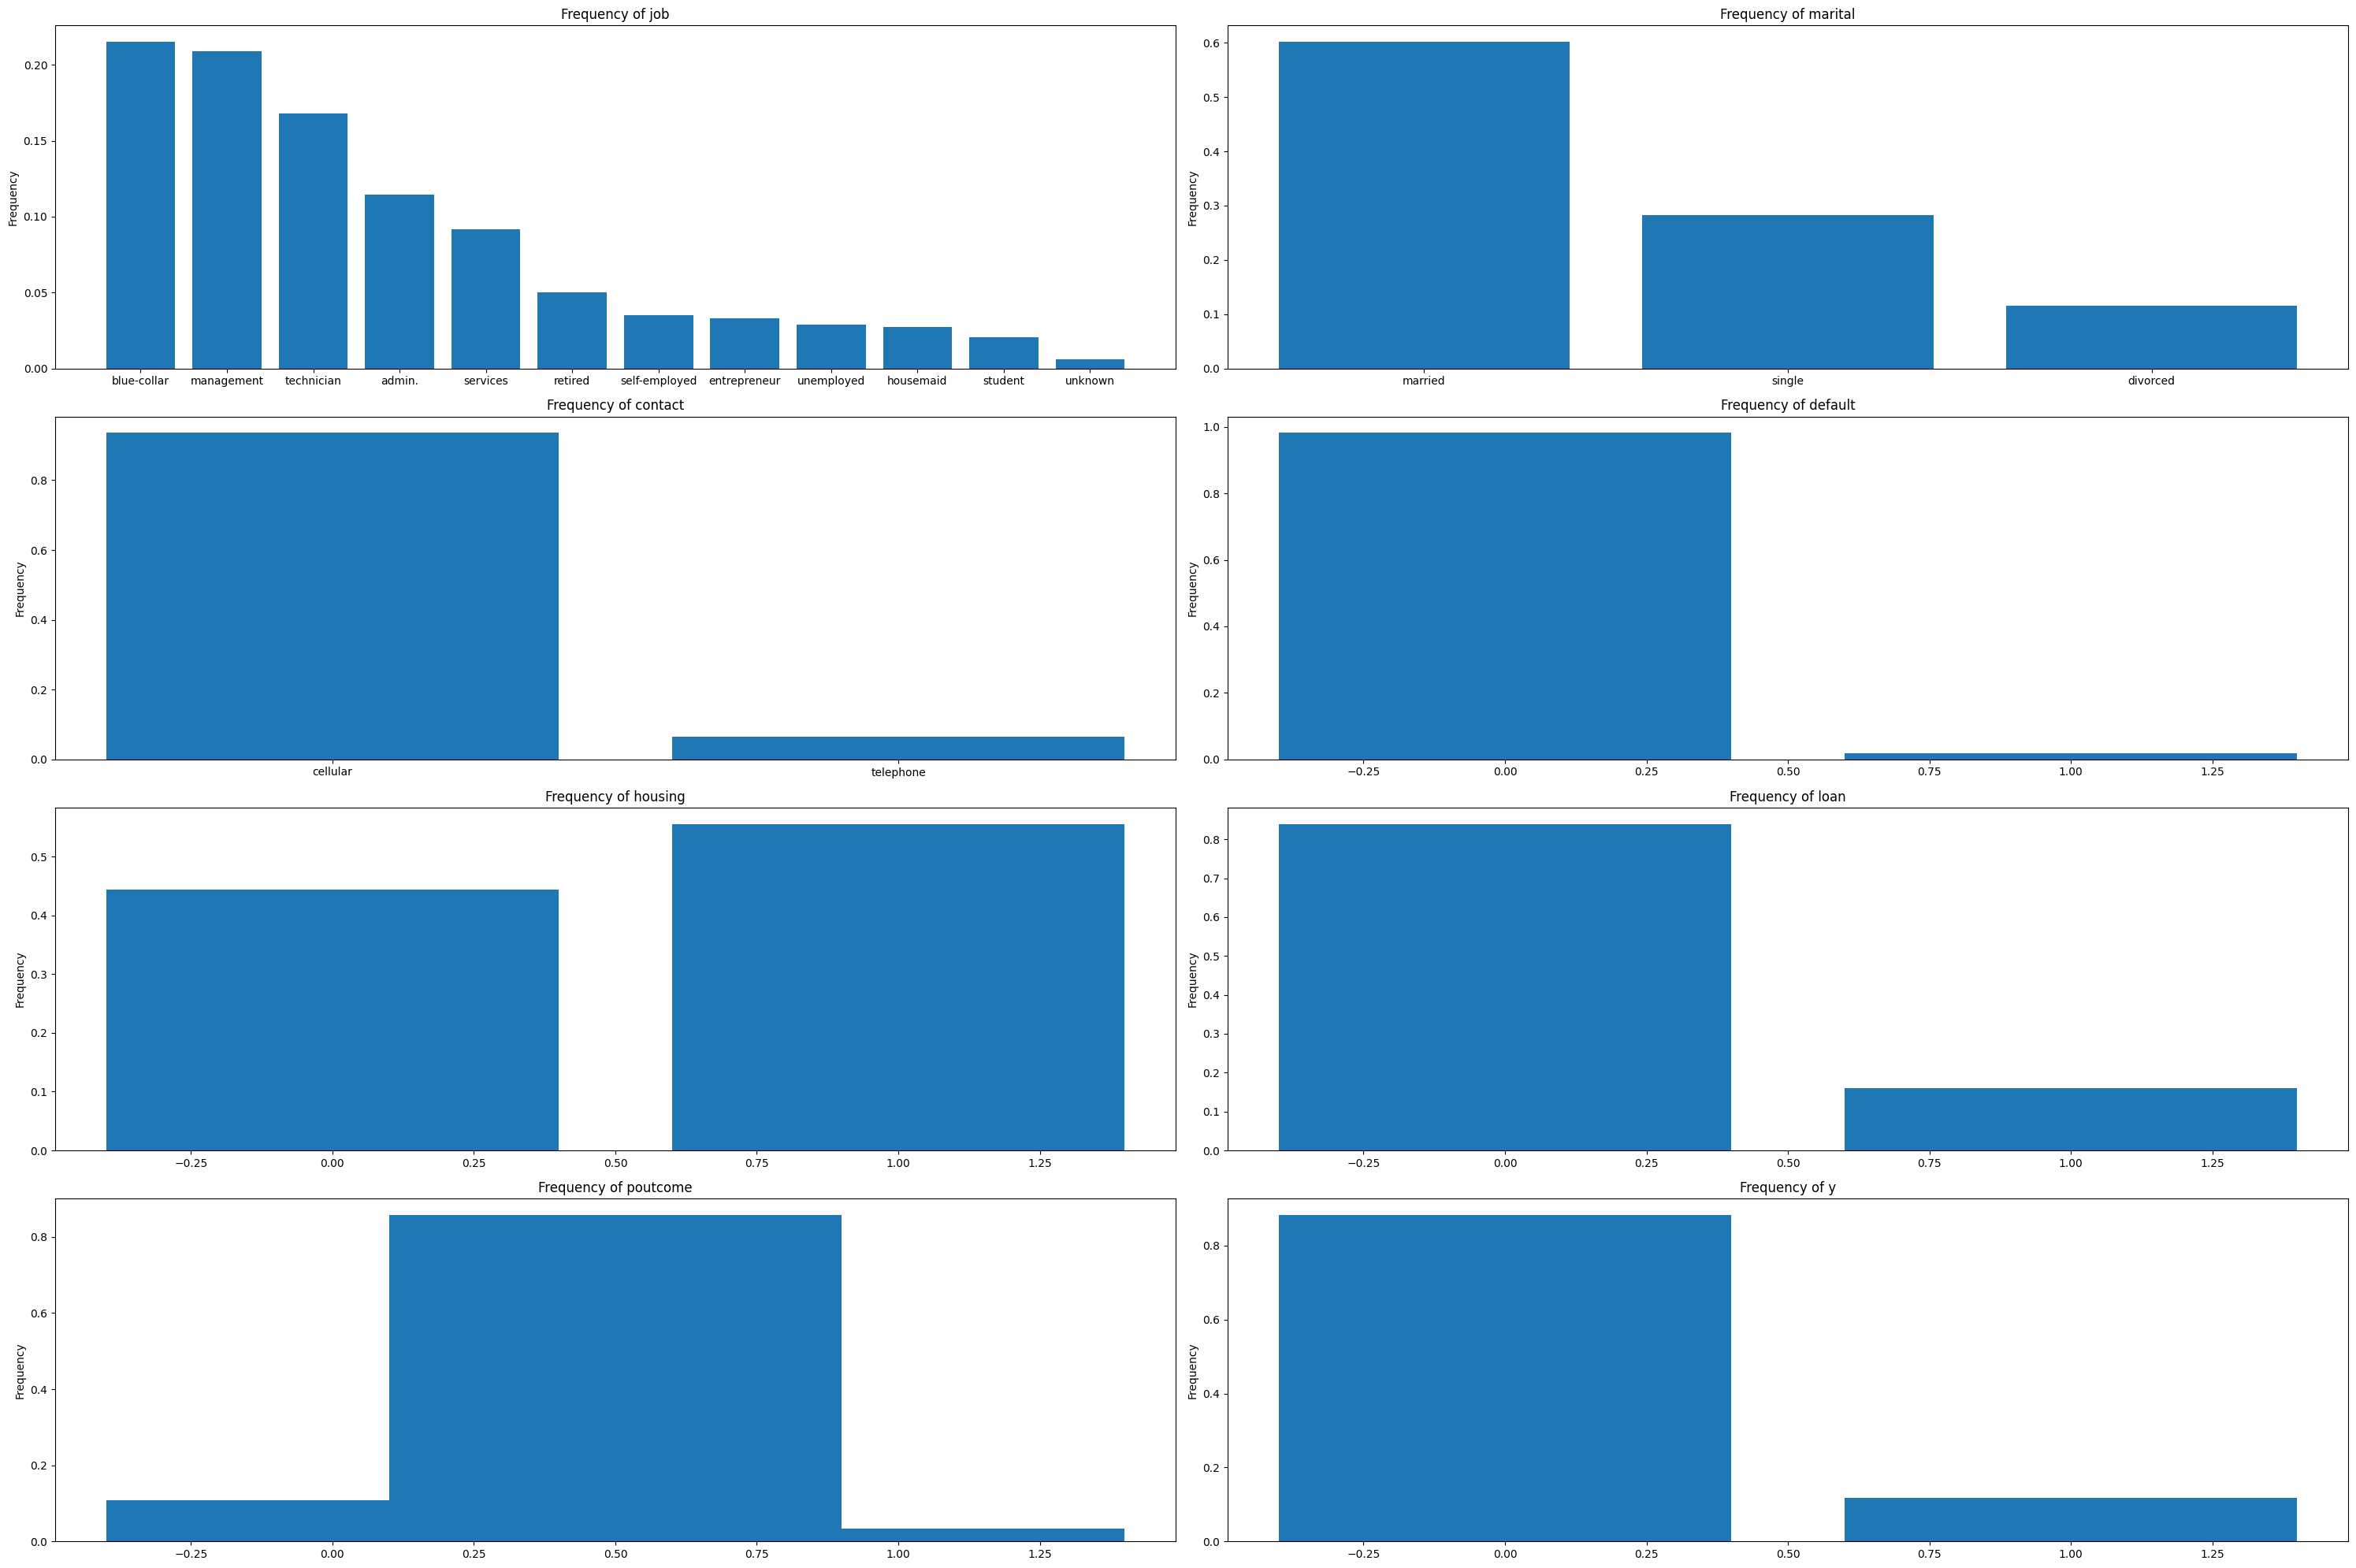

In [ ]:
# frequency analysis for categorical variable and encoded numerical variables:
import matplotlib.pyplot as plt

# categorical variables (job, marital, contact) and encoded numerical variables ('default', 'housing', 'loan', 'poutcome', 'y')
# categorical_columns = data.select_dtypes(include=['object']) # returned(job, marital, contact)

# Calculate frequencies of each category for all variables
category_counts = {}
target_list=['job', 'marital', 'contact', 'default', 'housing', 'loan', 'poutcome', 'y']
for col in target_list:
    # (NOTE) if you wanna see counts
    # category_counts[col] = data[col].value_counts()

    # (NOTE) if you wanna see percentages
    category_counts[col] = data[col].value_counts(normalize=True)

# subplots
fig, axes = plt.subplots(4, 2, figsize=(30, 20))

# Plot frequencies for each variable
for i, column in enumerate(target_list):
    row = i // 2
    col = i % 2
    if row < 4 and col < 2:
        axes[row,col].bar(category_counts[column].index, category_counts[column].values)
        axes[row,col].set_title(f'Frequency of {column}')
        axes[row,col].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

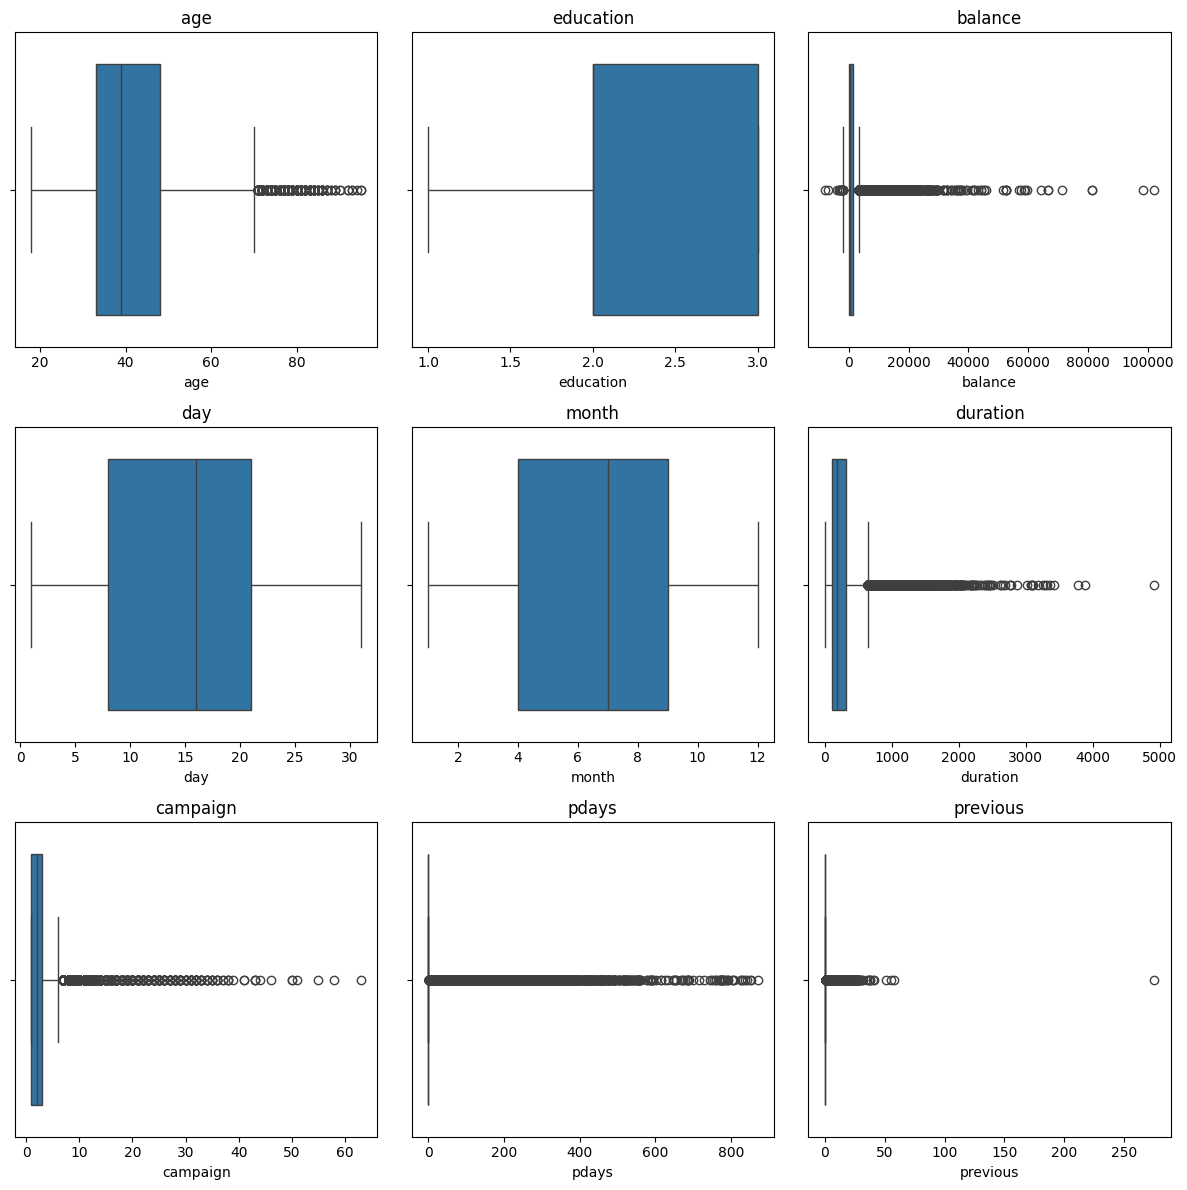

In [ ]:
# Univariate analysis:
import matplotlib.pyplot as plt
import seaborn as sns

# outlier detection
# age, education, default, balance, housing, loan, day, month, duration, campaign, pdays, previous, poutcome, y
num_rows = 3
num_cols = 3
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 12))

# exclude poutcome and y
# Plot each numeric column's box plot
for i, column in enumerate(data.select_dtypes(include=['number']).drop(['default', 'housing', 'loan', 'poutcome', 'y'],axis=1).columns):
    row = i // num_cols
    col = i % num_cols
    if row < num_rows and col < num_cols:
        sns.boxplot(x=data[column], ax=axes[row, col])
        axes[row, col].set_title(column)

# Adjust layout
plt.tight_layout()
plt.show()

# outlier detection analysis:

* day, and month are good (approximately normal)
* education is also ok (but left skewed)
<br><br>
* age: there is a bunch of elders who become outliers, but I don't think we should remove them nor scaled them (why normalize age?).
* balance, duration, campaign: right skewed with bunch of outliers and some extreme datapoints (just remove some extreme ones)
* pdays: bunch of outliers, but I don't suggest removing (there is no point unless we take out all of them XD)

# handling unknowns:

* unknown existed in job, education, contact, poutcome--> now only job
*
* print(data['job'].value_counts(normalize=True)) # 278 unknowns, or 0.006149 aka 0.6%


* not going to handle it becuase it's hard to assign jobs to adult, need more information


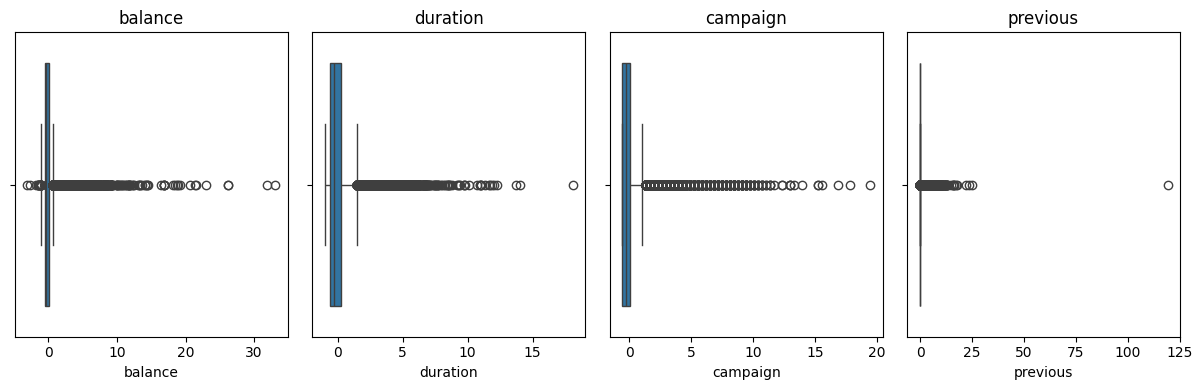

In [ ]:
# Outlier removal - I will probably only remove only a few extreme ones

# observe true outliers by standardize first to see their relative positions
# fail safe
test=data.copy()

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
test['balance']=scaler.fit_transform(test[['balance']])
test['duration']=scaler.fit_transform(test[['duration']])
test['campaign']=scaler.fit_transform(test[['campaign']])
test['previous']=scaler.fit_transform(test[['previous']])

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
test_list=['balance', 'duration', 'campaign', 'previous']

# Plot each numeric column's box plot
for i, column in enumerate(test_list):
    sns.boxplot(x=test[column], ax=axes[i])
    axes[i].set_title(column)

# Adjust layout
plt.tight_layout()
plt.show()

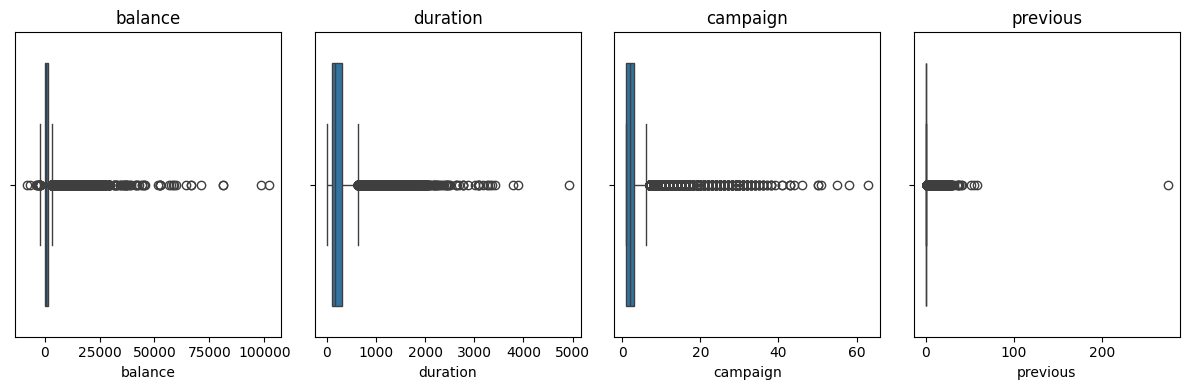

(45211, 17)
(45200, 17)


In [ ]:
# ACTUAL REMOVE
# relatively conservative identified from previous scale (plan to remove 11)
# new: plan to remove largest previous, largest duration, largest 2 balances,  not going to remove campaign (hard to identify)

# observe in full data

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
test_list=['balance', 'duration', 'campaign', 'previous']

# Plot each numeric column's box plot
for i, column in enumerate(test_list):
    sns.boxplot(x=data[column], ax=axes[i])
    axes[i].set_title(column)

# Adjust layout
plt.tight_layout()
plt.show()

# actual removing
print(data.shape) # returned (45211, 17)
adjusted_data=data.loc[~((data['previous']>45)| (data['balance']> 80000)| (data['duration']> 3600))]
print(adjusted_data.shape) # returned (45200, 17)

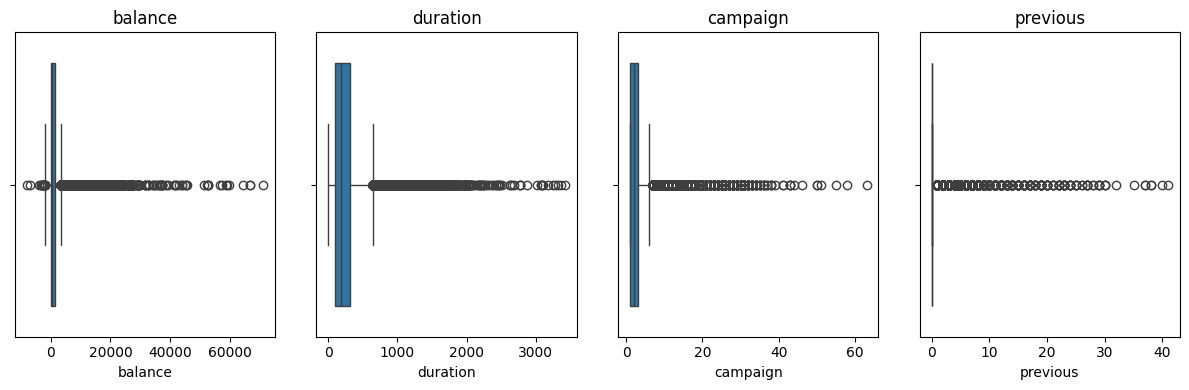

In [ ]:
# plot once more to check (confirmed)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
test_list=['balance', 'duration', 'campaign', 'previous']

# Plot each numeric column's box plot
for i, column in enumerate(test_list):
    sns.boxplot(x=adjusted_data[column], ax=axes[i])
    axes[i].set_title(column)

# Adjust layout
plt.tight_layout()
plt.show()

# Concluion for outlier removal:
* removed 11 datapoints, returned (45200, 17)
* can be addjusted later for more aggressive/ conservative

# Data Normalization/ Standardization

* Conclusion: since we plan to use tree-based method which are insensitive to the magnitude of variables. I don't suggest to do so

In [ ]:
# # Multivariate analysis- print pairwise scatterplot for each x to y
# # Warning: takes a long time to run (~ 10 mins)
# import seaborn as sns
# sns.pairplot(adjusted_data, hue="y")

# Observation:

* rarely any linear relationships (which is expected to be honest).
* Hard to observe any obvious patterns (aside from a few on the upper triangle)
* I would say insignificant to no mutlicolienarity.
* No distinct outliers after outlier removal

In [ ]:
# encode all data first for fitting

adjusted_data.select_dtypes(include=['object']).columns

# encode job, marital, and contact with one-hot encoding
# adjusted_data['job'] # HARD AF

# let's try on contact first
test=adjusted_data.copy()

encoded_test=pd.get_dummies(test, columns=['contact', 'marital', 'job'])
encoded_test

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
0,58,3,0,2143,1,0,5,9,261,1,...,False,False,True,False,False,False,False,False,False,False
1,44,2,0,29,1,0,5,9,151,1,...,False,False,False,False,False,False,False,True,False,False
2,33,2,0,2,1,1,5,9,76,1,...,True,False,False,False,False,False,False,False,False,False
3,47,2,0,1506,1,0,5,9,92,1,...,False,False,False,False,False,False,False,False,False,False
4,33,2,0,1,0,0,5,9,198,1,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,3,0,825,0,0,17,10,977,3,...,False,False,False,False,False,False,False,True,False,False
45207,71,1,0,1729,0,0,17,10,456,2,...,False,False,False,True,False,False,False,False,False,False
45208,72,2,0,5715,0,0,17,10,1127,5,...,False,False,False,True,False,False,False,False,False,False
45209,57,2,0,668,0,0,17,10,508,4,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# reassign back once encoded - for safety reasons
adjusted_data=encoded_test

In [ ]:
# Feature engineering:

# Build a new feature (numDays): to combine month and day to get number of days,

# Calculate number of days in a year using lambda function
adjusted_data['days_in_year'] = adjusted_data.apply(lambda row: 366 if row['month'] == 2 and row['day'] == 29 else 365
                                        if row['month'] == 2 else sum([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31][:int(row['month'])]) + int(row['day']) - 30, axis=1)

<ipython-input-14-078fc6b01e61>:12: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  testrf.fit(x, y)


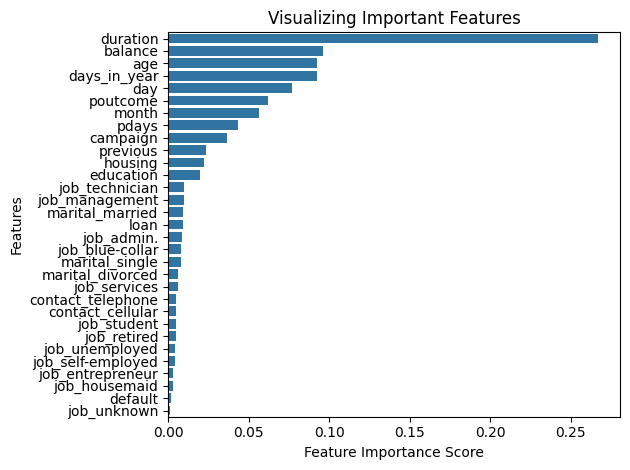

In [ ]:
# feature importance model (investigate relationship for clasification problems)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# identify x and y first
x=adjusted_data.loc[:, adjusted_data.columns !='y']
y=adjusted_data.loc[:, adjusted_data.columns =='y']

# fitting the entire data just to observe fetaure importnce
testrf=RandomForestClassifier()
testrf.fit(x, y)
importances=testrf.feature_importances_

# Plot out the features' importance using a barplot
feature_imp = pd.Series(importances, index=x.columns).sort_values(ascending=False)
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features")
plt.tight_layout()


In [ ]:
# export to csv for prepared data
print(adjusted_data.shape) # returned (45200, 31)
adjusted_data.to_csv("processedInput.csv", header=True, index=False) # success

(45200, 32)


In [ ]:
# try to split the data once read
import pandas as pd

processed_data=pd.read_csv("https://raw.githubusercontent.com/Alex-Mak-MCW/Deposit_Subcriptions_Predictions_Project/main/Data/processedInput.csv", sep=",")
# print(processed_data.shape) #(45200, 31)--> good

# identify x and y first
x=processed_data.loc[:, processed_data.columns !='y']
y=processed_data.loc[:, processed_data.columns =='y']

# NOTE: drop day and month in x
x.drop(columns=['day', 'month'], inplace=True)

<ipython-input-16-5502deff9c00>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.drop(columns=['day', 'month'], inplace=True)


In [ ]:
# Implement DT:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.utils import check_random_state

# set random seed for code reproducability
random_state=check_random_state(7)

# 1. data splitting into train-test-validation split (80-10-10)
# first split train as 80%, rest 20%
X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.2)

# split the 20% by half (10% test, 10% validation)
X_val, X_test, y_val, y_test=train_test_split(X_test,y_test,test_size=0.5)


# 2. train and fit a decision tree model using the training data
DT = DecisionTreeClassifier()
DT.fit(X_train, y_train)

# 2.1 make predictions on the testing data based on the pre-tuned model fitted with training data
DT_y_train_pred=DT.predict(X_test)
# Accuracy Score, they are around 89-91%
print("Training (Pre-tuned) Accuracy on Decision Tree: {}".format(accuracy_score(y_test, DT_y_train_pred)))

Training (Pre-tuned) Accuracy on Decision Tree: 0.8665929203539823


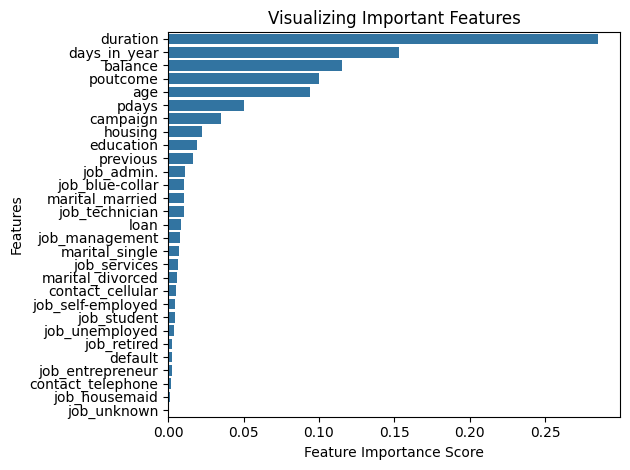

In [ ]:
# 3. model analysis: interpret feature importance
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

# 3.1 make predictions on y using training data's x
DT_train_pred=DT.predict(X_test)

# 3.2 measure importance of each features to further improve the model
DT_feature_imp = pd.Series(DT.feature_importances_, index=X_train.columns).sort_values(ascending=False)
# print("Accuracy: {}".format(metrics.accuracy_score(y_test, DT_train_pred))) # 0.8752212389380531

# Plot out the features' importance using a barplot
sns.barplot(x=DT_feature_imp, y=DT_feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features")
plt.tight_layout()

plt.savefig("DT_feature_importance.png")
plt.show()
# The ones I regard as important are the ones without jobs and marriage status (keeping everything till loan)

In [ ]:
# 4. Variable selection & use the vaildiation data to perform hyperparameter tuning
from sklearn.metrics import accuracy_score

# new_cols=['duration', 'balance', 'days_in_year', 'age', 'poutcome', 'day', 'pdays', 'month', 'campaign', 'education', 'previous', 'housing','loan']
new_cols=['duration', 'balance', 'days_in_year', 'age', 'poutcome', 'pdays', 'campaign', 'education', 'previous', 'housing','loan'] # without day and month

# Removing less important features on training, testing, and validtion  (11 columns left)
DT_X_train = X_train.loc[:, new_cols]   # (36160, 11)
DT_X_test = X_test.loc[:, new_cols]     # (4520, 11)
DT_X_val = X_val.loc[:, new_cols]       # (4520, 11)

# 4.1: Define the hyperparameters to tune
# Grid search CV (cross validation) to find the best hyperparameters for tuning
DT_param_grid = {
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [3, 6, 9],
    'max_leaf_nodes': [3, 6, 9],
    'criterion': ['gini', 'entropy', 'log_loss'],
    # 'splitter': ['best', 'random'],
    'min_samples_split' : [2, 3, 6, 9],
    'min_samples_leaf' : [1, 3, 6, 9],
}

# 4.2: Perform grid search cross-validation (5 fold CV)
DT_grid_search = GridSearchCV(DT, DT_param_grid, cv=5, scoring='accuracy')
DT_grid_search.fit(DT_X_val, y_val)

# 4.3: Get the best hyperparameters
DT_best_params = DT_grid_search.best_params_
# print(DT_best_params) # success

# 5. refit the model with the best parameter
DT_best_model = DecisionTreeClassifier(**DT_best_params)

# reshaped y to ensure it fits
DT_best_model.fit(DT_X_train, y_train.values.reshape(1,-1)[0])

# 6. Make predictions of the actual model and obtain accuracy
DT_y_test_pred=DT_best_model.predict(DT_X_test)

# Accuracy Score, they are around 89-91%
print("Testing (Post-tuned) Accuracy from manual tuning on Decision Tree: {}".format(accuracy_score(y_test, DT_y_test_pred)))

Testing (Post-tuned) Accuracy from manual tuning on Decision Tree: 0.9024336283185841


In [ ]:
# 4. AUTOMATED Variable selection & use the vaildiation data to perform hyperparameter tuning
# tuning pipeline:
# Warning: ALMOST 9 mins to run

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV

# 4.1 Define Pipeline
DT_pipeline = Pipeline([
    # Variable Selection and Hyperparameter Tuning
    ('feature_selection', SelectFromModel(DecisionTreeClassifier())),
    ('classifier', DT)
])

# 4.2 define param grid for pipeline only
DT_pipeline_param_grid= {
    'feature_selection__estimator__criterion': ['gini', 'entropy'],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__max_depth': [3, 6, 9],
    'classifier__max_leaf_nodes': [3, 6, 9],
    'classifier__criterion': ['gini', 'entropy', 'log_loss'],
    'classifier__min_samples_split' : [2, 3, 6, 9],
    'classifier__min_samples_leaf' : [1, 3, 6, 9],
}

DT_pipeline.fit(X_val,y_val)

# Get the selected features
selected_features = DT_pipeline.named_steps['feature_selection'].get_support()

# Print selected features
print("Selected Features for Decision Tree:")
for feature, selected in zip(X_val.columns, selected_features):
    if selected:
        print(feature)

# 4.3 Perform Grid Search CV
DT_grid_search = GridSearchCV(DT_pipeline, DT_pipeline_param_grid, cv=5)

# 4.4 refit the model with grid search
DT_grid_search.fit(X_val, y_val)

Selected Features for Decision Tree:
age
balance
duration
campaign
pdays
poutcome
days_in_year


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('feature_selection',
                                        SelectFromModel(estimator=DecisionTreeClassifier())),
                                       ('classifier',
                                        DecisionTreeClassifier())]),
             param_grid={'classifier__criterion': ['gini', 'entropy',
                                                   'log_loss'],
                         'classifier__max_depth': [3, 6, 9],
                         'classifier__max_features': ['sqrt', 'log2', None],
                         'classifier__max_leaf_nodes': [3, 6, 9],
                         'classifier__min_samples_leaf': [1, 3, 6, 9],
                         'classifier__min_samples_split': [2, 3, 6, 9],
                         'feature_selection__estimator__criterion': ['gini',
                                                                     'entropy']})

In [ ]:
# 4.5 obtain the best parameter from the pipeline
DT_best_params = DT_grid_search.best_params_
print(DT_best_params)

# 5. Refit the model with the best parameters
DT_pipeline.set_params(**DT_best_params)
DT_pipeline.fit(X_train, y_train)

# 6. Make predictions of the actual model and obtain accuracy
DT_y_pred = DT_pipeline.predict(X_test)

# 6.1 Calculate accuracy: around
DT_pipeline_accuracy = DT_pipeline.score(X_test, y_test)
print("Testing (Post-tuned) Accuracy from automated tuning on Decision Tree: {}".format(DT_pipeline_accuracy))

{'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__max_features': 'log2', 'classifier__max_leaf_nodes': 9, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 6, 'feature_selection__estimator__criterion': 'gini'}
Testing (Post-tuned) Accuracy from automated tuning on Decision Tree: 0.8997787610619469


In [ ]:
# Accuracy comparsion

print("For Decision Tree:")

print("\nBefore hyperparameter tuning:")
print("Training (Pre-tuned) Accuracy: \t\t\t\t{0}% \t({1})".format(accuracy_score(y_test, DT_y_train_pred)*100, accuracy_score(y_test, DT_y_train_pred)))
print("\nAfter hyperparameter tuning:")
print("Testing (Post-tuned) Accuracy from manual tuning: \t{0}% \t({1})".format(accuracy_score(y_test, DT_y_test_pred)*100, accuracy_score(y_test, DT_y_test_pred)))
print("Testing (Post-tuned) Accuracy from automated tuning: \t{0}% \t({1})".format(DT_pipeline_accuracy*100, DT_pipeline_accuracy))

print("---------------------------------------")
print("Training Accuracy: \t{0}% \t({1})".format(DT_pipeline.score(X_train, y_train)*100, DT_pipeline.score(X_train, y_train)))
print("Test Accuracy: \t{0}% \t({1})".format(DT_pipeline.score(X_test, y_test)*100, DT_pipeline.score(X_test, y_test)))

For Decision Tree:

Before hyperparameter tuning:
Training (Pre-tuned) Accuracy: 				86.65929203539822% 	(0.8665929203539823)

After hyperparameter tuning:
Testing (Post-tuned) Accuracy from manual tuning: 	90.2433628318584% 	(0.9024336283185841)
Testing (Post-tuned) Accuracy from automated tuning: 	89.97787610619469% 	(0.8997787610619469)
---------------------------------------
Training Accuracy: 	89.94745575221239% 	(0.8994745575221239)
Test Accuracy: 	89.97787610619469% 	(0.8997787610619469)


In [ ]:
# Naming conventions: ensure either automate or manual hyperparameter tuning doesn't impact other code
DT_X_train = X_train
DT_X_val = X_val
DT_X_test=X_test

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      4000
           1       0.61      0.37      0.46       520

    accuracy                           0.90      4520
   macro avg       0.76      0.67      0.70      4520
weighted avg       0.89      0.90      0.89      4520



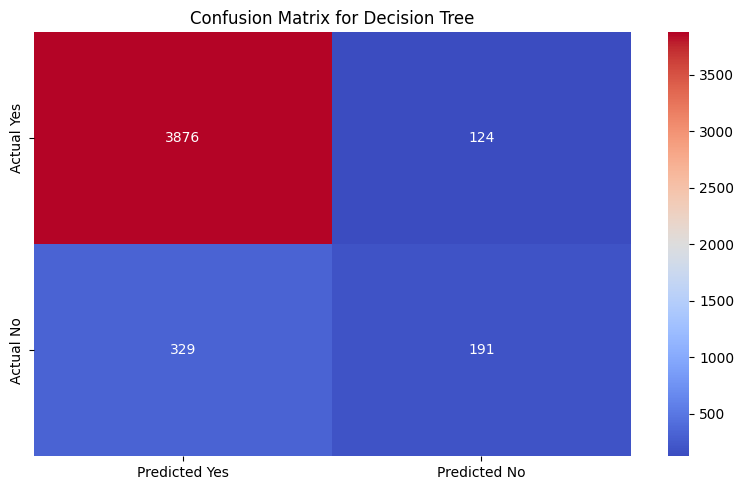

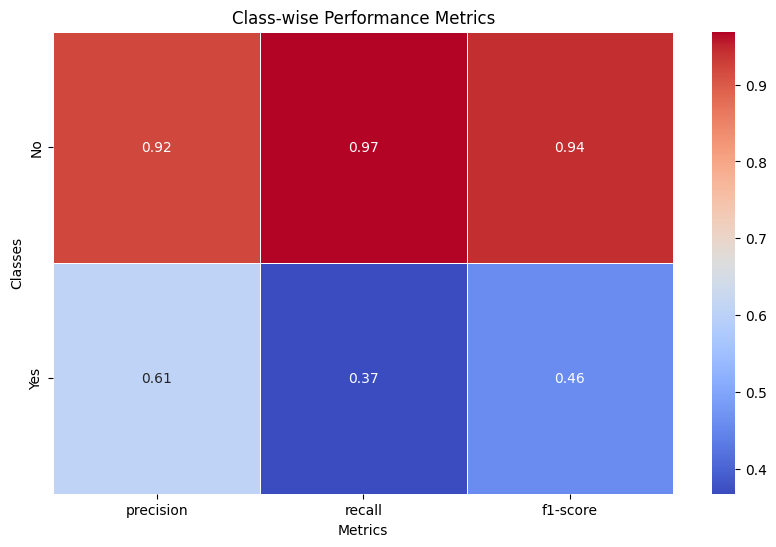

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# 7. Visualize the output
# 7.1 classification report
DT_classification_report=classification_report(y_test, DT_y_pred)
print(DT_classification_report)

# 7.2 Confusion matrix with seaborn heatmap
DT_conf_matrix=confusion_matrix(y_test, DT_y_pred)
# Seaborn heatmap
plt.figure(figsize=(8,5))
sns.heatmap(DT_conf_matrix, annot=True, fmt="d", cmap='coolwarm', xticklabels=['Predicted Yes', 'Predicted No'], yticklabels=['Actual Yes', 'Actual No'])
plt.title('Confusion Matrix for Decision Tree')
plt.tight_layout()
plt.savefig("DT_confusion_matrix.png")

# 7.3 Visualize classification report better: Class-wise Performance Metrics
DT_classification_report_2 = classification_report(y_test, DT_y_pred, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
class_metrics = {metric: [DT_classification_report_2[class_name][metric] for class_name in ['0','1']] for metric in metrics}

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data=pd.DataFrame(class_metrics, index=['No','Yes']), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Class-wise Performance Metrics')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.savefig("DT_performance_metrics.png")
plt.show()

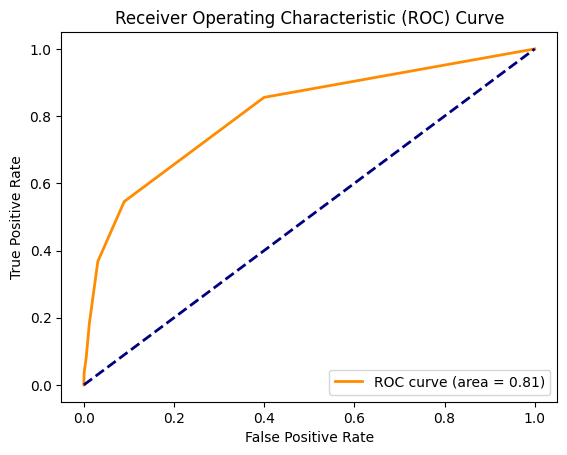

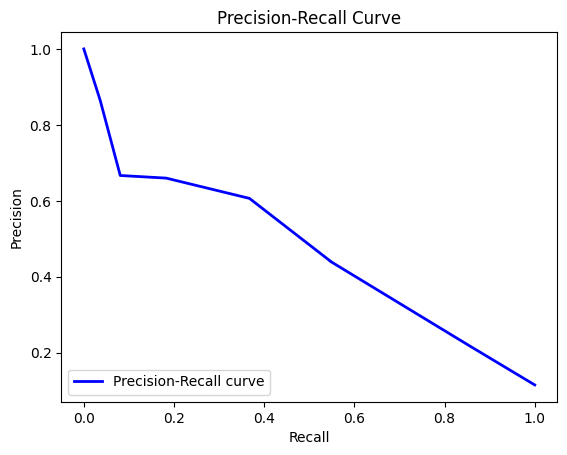

In [ ]:
# More visualization
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# NOTE: only choose 1 of the following 2 methods:

# manual hyperparameter tuning
# DT_y_scores = DT_best_model.predict_proba(DT_X_test)[:, 1]

# automate hyperparameter tuning (pipeline)
DT_y_scores=DT_pipeline.predict_proba(X_test)[:, 1]


# 7.4 ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, DT_y_scores)

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig("DT_roc_curve.png")

# 7.5 Precision-Recall Curve (Keep it for now, can be deleted)
precision, recall, thresholds = precision_recall_curve(y_test, DT_y_scores)
plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.savefig("DT_precision_recall_curve.png")
plt.show()

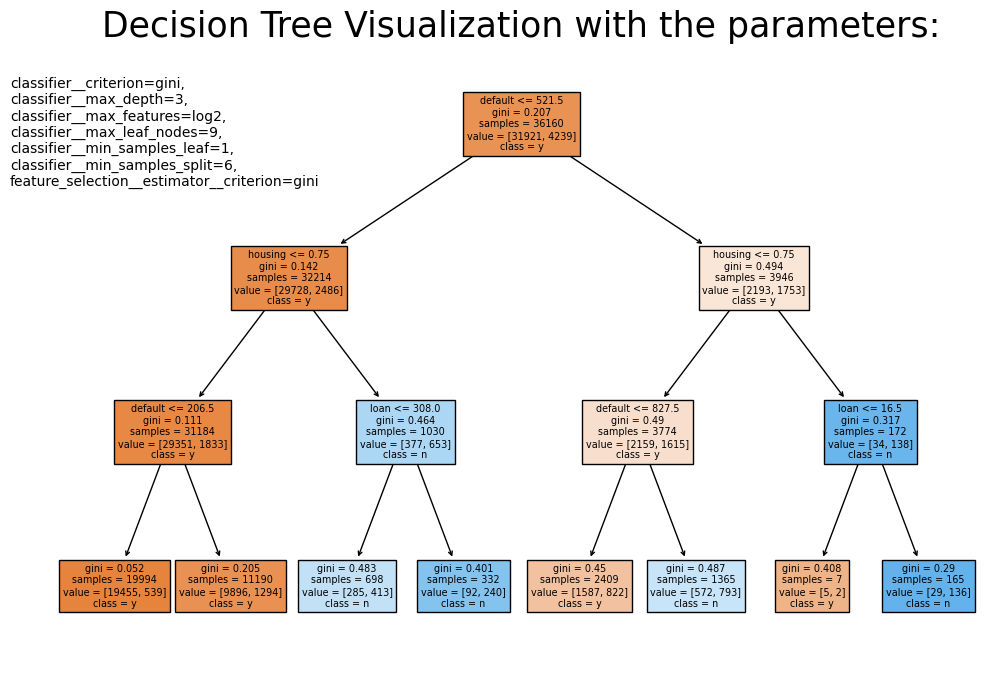

In [ ]:
# 7.6 Visualize the decision tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# convert hyperparameter values in a string (only works in both manual and automatic tuning)
# DT_param_str = ', '.join([f"{key}={val}" for key, val in DT_best_params.items()]) # for manual
DT_param_str = ',\n'.join([f"{key}={val}" if index % 2 == 0 else f"{key}={val}" for index, (key, val) in enumerate(DT_best_params.items())]) # for automatic

# Visualize the decision tree
plt.figure(figsize=(12, 8))
# manual hyperparmeter
# plot_tree(DT_best_model, feature_names=DT_X_train.columns, class_names=['y', 'n'], filled=True)

# automated hyperparameter
DT_pipeline_classifier = DT_pipeline.named_steps['classifier']

plot_tree(DT_pipeline_classifier, feature_names=DT_X_train.columns, class_names=['y', 'n'], filled=True)
plt.title("Decision Tree Visualization with the parameters:\n\n", fontsize=25, y=0.875)
plt.text(x=-0.05, y=0.775, s=DT_param_str, fontsize=10)
plt.savefig("DT_visualizations.png")
plt.show()

#**Random Forest**

##**1. Create a Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Create a Random Forest classifier using the default n_estimators value of 100
RF = RandomForestClassifier(n_estimators=100, random_state=7)

# Fit the classifier to the training data
RF.fit(X_train, y_train.values.reshape(len(y_train),))       # A warning appeared asking for y_train to be reshaped, hence the use of .reshape() here

RF_y_train_pred=RF.predict(X_test)
# Accuracy Score, they are around 89-91%
print("Training (Pre-tuned) Accuracy on Random Forest: {}".format(accuracy_score(y_test, RF_y_train_pred)))

Training (Pre-tuned) Accuracy on Random Forest: 0.9028761061946903


###**Will remove the following code snippet if we are not curious about what Random Forest thinks the most important features are**

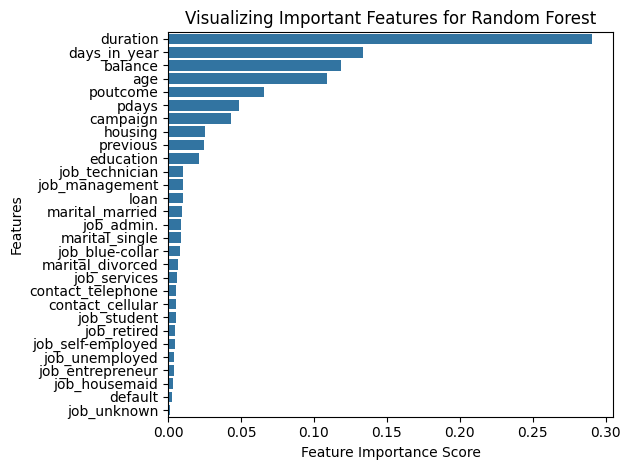

In [ ]:
# Make predictions on y using training data's x
RF_train_pred = RF.predict(X_test)

# Measure the importance of each features to further improve the model
RF_feature_imp = pd.Series(RF.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot the features' importance using a barplot
sns.barplot(x=RF_feature_imp, y=RF_feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features for Random Forest")
plt.tight_layout()

plt.savefig("RF_feature_importance.png")
plt.show()

##**2. Perform hyperparameter tuning using Grid Search**

###**!!!Beware: the following code snippet can take up to 30+ minutes to run**

In [69]:
# We will also use a pipeline here to select the most important features and perform classification using Random Forest
RF_pipeline = Pipeline([
    ('feature_selection', SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=7))),
    ('classifier', RF)
])

# Define param grid
# Used to include more parameter values but it took so long (> 1 hour)
# Now using only a few more common parameter values for Grid Search
RF_pipeline_param_grid= {
    'classifier__n_estimators': [50, 100],
    'feature_selection__estimator__criterion': ['gini', 'entropy'],
    'feature_selection__estimator__bootstrap' : [True, False],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__max_depth': [6, 9],
    'classifier__criterion': ['gini', 'entropy', 'log_loss'],
    'classifier__min_samples_split' : [6, 9],
    'classifier__min_samples_leaf' : [1, 6, 9]
}

RF_pipeline.fit(X_val,y_val)

# Get the selected features
selected_features = RF_pipeline.named_steps['feature_selection'].get_support()

# Print selected features
print("Selected Features For Random Forest:")
for feature, selected in zip(X_val.columns, selected_features):
    if selected:
        print(feature)

# Perform Grid Search CV with cv=5
RF_grid_search = GridSearchCV(RF_pipeline, RF_pipeline_param_grid, cv=5, n_jobs=-1)

# Fit the model with grid search
RF_grid_search.fit(X_val, y_val.values.reshape(len(y_val),))

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_from_model.py:357: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.estimator_.fit(X, y, **fit_params)
/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py:405: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self._final_estimator.fit(Xt, y, **fit_params_last_step)


Selected Features For Random Forest:
age
balance
duration
campaign
pdays
poutcome
days_in_year


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('feature_selection',
                                        SelectFromModel(estimator=RandomForestClassifier(random_state=7))),
                                       ('classifier',
                                        RandomForestClassifier(max_depth=9,
                                                               min_samples_split=9,
                                                               random_state=7))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy',
                                                   'log_loss'],
                         'classifier__max_depth': [6, 9],
                         'classifier__max_features': ['sqrt', 'log2'],
                         'classifier__min_samples_leaf': [1, 6, 9],
                         'classifier__min_samples_split': [6, 9],
                         'classifier__n_estimators': [50, 100],
                         'feature_selection__estimator__bootstrap': [True,
                                                                     False],
                         'feature_selection__estimator__criterion': ['gini',
                                                                     'entropy']})

In [71]:
import joblib

# Save the trained model
joblib.dump(RF_grid_search.best_estimator_, 'random_forest_model.pkl')
joblib.dump(RF_grid_search.best_params_, 'rf_best_params.joblib')

# Load the saved model
loaded_model = joblib.load('random_forest_model.pkl')
loaded_best_params = joblib.load('rf_best_params.joblib')

##**3. Compute the model's accuracy using the best hyperparameter combination**

In [70]:
# Display the best hyperparameter combination from Grid Search
RF_best_params = RF_grid_search.best_params_
print("The best hyperparameter combination is: ", RF_best_params)

# Refit the Random Forest classifier with the best hyperparameters
RF_pipeline.set_params(**RF_best_params)
RF_pipeline.fit(X_train, y_train.values.reshape(len(y_train),))

# Make predictions using the Random Forest classifier
RF_y_pred = RF_pipeline.predict(X_test)

# Calculate the accuracy
RF_pipeline_accuracy = RF_pipeline.score(X_test, y_test)
print("Tuned Accuracy using Pipeline (Random Forest): {}".format(RF_pipeline_accuracy))

The best hyperparameter combination is:  {'classifier__criterion': 'gini', 'classifier__max_depth': 9, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 9, 'classifier__n_estimators': 100, 'feature_selection__estimator__bootstrap': True, 'feature_selection__estimator__criterion': 'gini'}
Tuned Accuracy using Pipeline (Random Forest): 0.904424778761062


In [ ]:
# Accuracy comparsion
print("For Random Forest:")

print("\nBefore hyperparameter tuning:")
print("Training (Pre-tuned) Accuracy: \t\t\t\t{0}% \t({1})".format(accuracy_score(y_test, RF_y_train_pred)*100, accuracy_score(y_test, RF_y_train_pred)))
print("\nAfter hyperparameter tuning:")
print("Testing (Post-tuned) Accuracy from automated tuning: \t{0}% \t({1})".format(RF_pipeline_accuracy*100, RF_pipeline_accuracy))

print("---------------------------------------")
print("Training Accuracy: \t{0}% \t({1})".format(RF_pipeline.score(X_train, y_train)*100, RF_pipeline.score(X_train, y_train)))
print("Test Accuracy: \t{0}% \t({1})".format(RF_pipeline.score(X_test, y_test)*100, RF_pipeline.score(X_test, y_test)))

For Random Forest:

Before hyperparameter tuning:
Training (Pre-tuned) Accuracy: 				90.28761061946902% 	(0.9028761061946903)

After hyperparameter tuning:
Testing (Post-tuned) Accuracy from automated tuning: 	90.4424778761062% 	(0.904424778761062)
---------------------------------------
Training Accuracy: 	91.88053097345133% 	(0.9188053097345132)
Test Accuracy: 	90.4424778761062% 	(0.904424778761062)


##**4. Visualize the output**

In [ ]:
# Follow the previous section
# Naming conventions: ensure either automate or manual hyperparameter tuning doesn't impact other code
RF_X_train = X_train
RF_X_val = X_val
RF_X_test = X_test

###**Classification report, confusion matrix, and class-wise performance metrics**

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      4000
           1       0.65      0.37      0.47       520

    accuracy                           0.90      4520
   macro avg       0.79      0.67      0.71      4520
weighted avg       0.89      0.90      0.89      4520



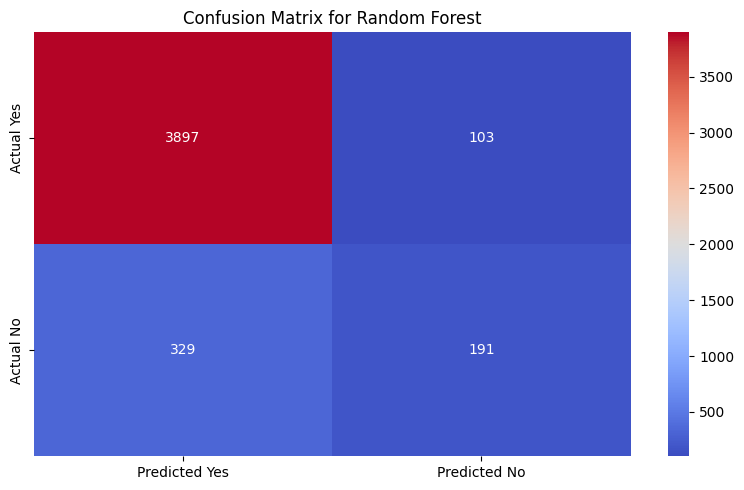

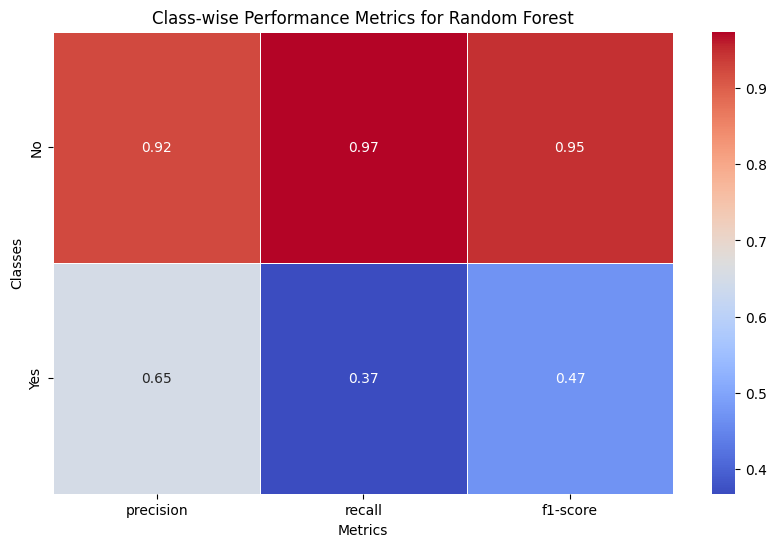

In [ ]:
# Classification report
RF_classification_report = classification_report(y_test, RF_y_pred)
print(RF_classification_report)

# Confusion matrix with seaborn heatmap
RF_conf_matrix = confusion_matrix(y_test, RF_y_pred)
plt.figure(figsize=(8,5))
sns.heatmap(RF_conf_matrix, annot=True, fmt="d", cmap='coolwarm', xticklabels=['Predicted Yes', 'Predicted No'], yticklabels=['Actual Yes', 'Actual No'])
plt.title('Confusion Matrix for Random Forest')
plt.tight_layout()
plt.savefig("RF_confusion_matrix.png")

# Class-wise Performance Metrics
RF_classification_report_2 = classification_report(y_test, RF_y_pred, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
class_metrics = {metric: [RF_classification_report_2[class_name][metric] for class_name in ['0','1']] for metric in metrics}
plt.figure(figsize=(10, 6))
sns.heatmap(data=pd.DataFrame(class_metrics, index=['No','Yes']), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Class-wise Performance Metrics for Random Forest')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.savefig("RF_performance_metrics.png")
plt.show()

###**ROC curve and precision-recall curve**

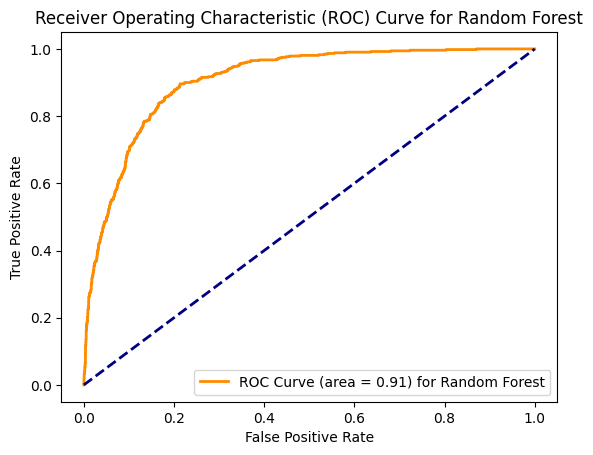

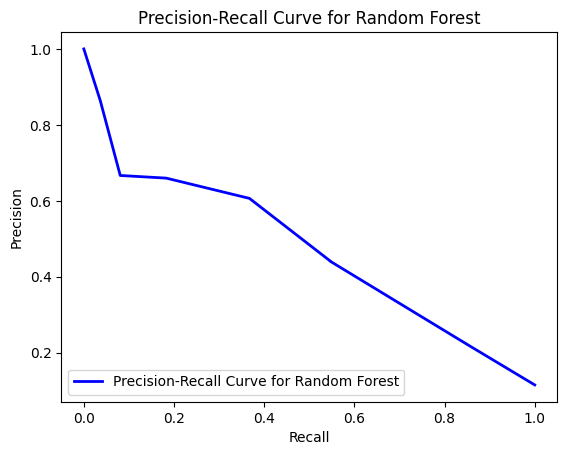

In [ ]:
RF_y_scores = RF_pipeline.predict_proba(X_test)[:, 1]

# ROC Curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, RF_y_scores)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='ROC Curve (area = %0.2f) for Random Forest' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.legend(loc="lower right")
plt.savefig("RF_roc_curve.png")

# Precision-Recall Curve
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, RF_y_scores)
plt.figure()
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall Curve for Random Forest')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Random Forest')
plt.legend(loc="lower left")
plt.savefig("RF_precision_recall_curve.png")
plt.show()

###**Visualize the first 5 trees in the Random Forest model**

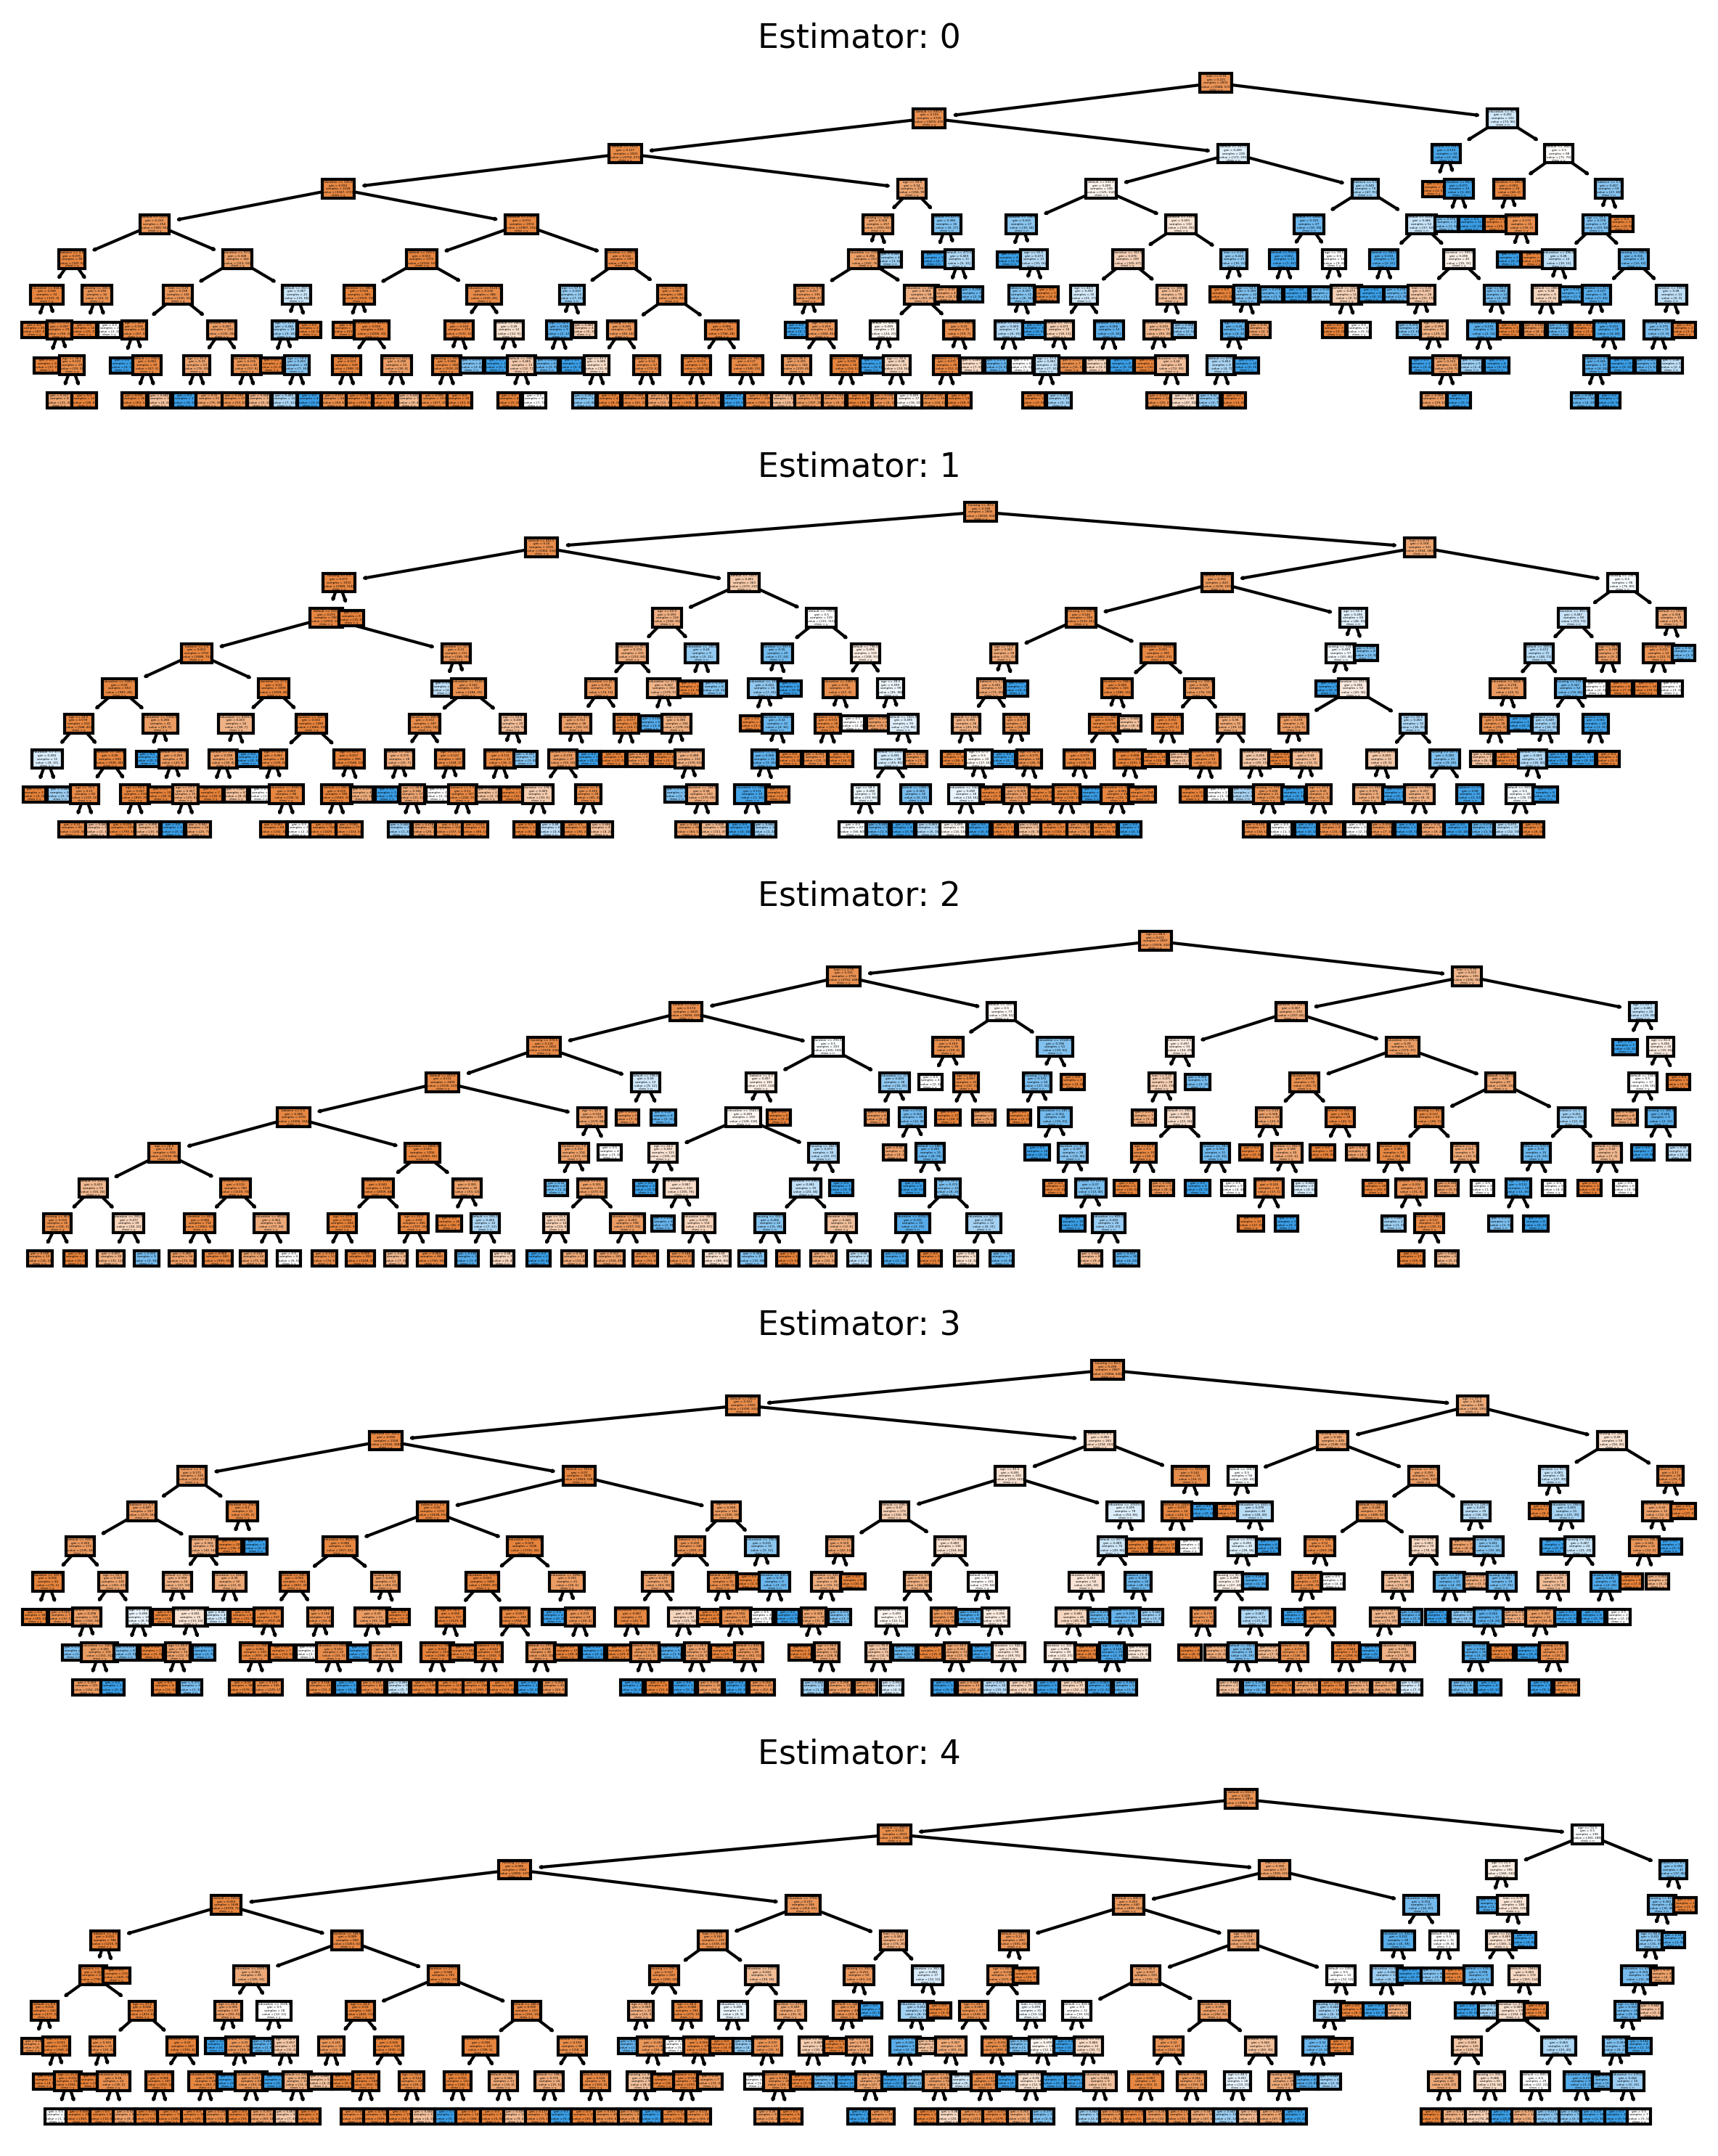

In [ ]:
# Create subplots for the first 5 trees
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(8, 10), dpi=300)

# Plot each decision tree
for i in range(5):
    RF_pipeline_classifier = RF_grid_search.best_estimator_.named_steps['classifier']
    plot_tree(RF_pipeline_classifier.estimators_[i], feature_names=RF_X_train.columns, class_names=['y', 'n'], filled=True, ax=axes[i])
    axes[i].set_title('Estimator: ' + str(i), fontsize=11)

# Adjust layout and save the figure
plt.tight_layout()
fig.savefig('RF_visualizations.png')

#**XGBoost**

##**1. Create a XGBoost Classifier**

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

# Create an instance of XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=7)

# Fit the Classifier to training data
xgb.fit(X_train, y_train)

xgb_y_train_pred=xgb.predict(X_test)
# Accuracy Score, they are around 89-91%
print("Training (Pre-tuned) Accuracy on Random Forest: {}".format(accuracy_score(y_test, xgb_y_train_pred)))

Training (Pre-tuned) Accuracy on Random Forest: 0.9077433628318584


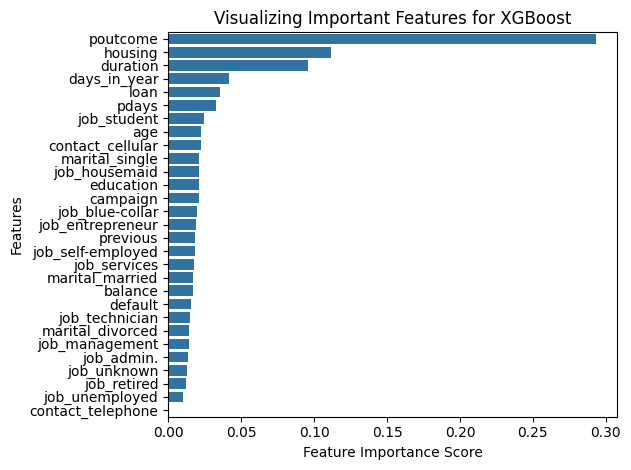

In [ ]:
# Make predictions on y using training data's x
xgb_train_pred = xgb.predict(X_test)

# Measure the importance of each features to further improve the model
xgb_feature_imp = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Plot the features' importance using a barplot
sns.barplot(x=xgb_feature_imp, y=xgb_feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features for XGBoost")
plt.tight_layout()

plt.savefig("XGBoost_feature_importance.png")
plt.show()

##**2. Perform hyperparameter tuning using Grid Search (20+ minutes to run)**

In [72]:
# We will also use a pipeline here to select the most important features and perform classification using Random Forest
xgb_pipeline = Pipeline([
    ('feature_selection', SelectFromModel(XGBClassifier(n_estimators=100, random_state=7))),
    ('classifier', xgb)
])

# Define param grid
# Used to include more parameter values but it took so long (> 1 hour)
# Now using only a few more common parameter values for Grid Search
# xgb_pipeline_param_grid= {
#     'classifier__n_estimators': [50, 100],
#     'feature_selection__estimator__bootstrap' : [True, False],
#     'classifier__max_features': ['sqrt', 'log2'],
#     'classifier__max_depth': [6, 9],
#     'classifier__criterion': ['gini', 'entropy', 'log_loss'],
#     'classifier__min_samples_split' : [2, 6, 9],
#     'classifier__min_samples_leaf' : [1, 6, 9]
# }
xgb_pipeline_param_grid = {
    'feature_selection__estimator__max_depth': [6, 9],
    'feature_selection__threshold': ['mean', 'median'],
    'classifier__learning_rate': [0.1, 0.01],
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [6, 9],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0],
    'classifier__gamma': [0, 0.1],
    'classifier__min_child_weight': [1, 5],
    'classifier__reg_lambda': [0, 0.1]
}

xgb_pipeline.fit(X_val,y_val)

# Get the selected features
selected_features = xgb_pipeline.named_steps['feature_selection'].get_support()

# Print selected features
print("Selected Features For XGBoost:")
for feature, selected in zip(X_val.columns, selected_features):
    if selected:
        print(feature)

# Perform Grid Search CV with cv=5
xgb_grid_search = GridSearchCV(xgb_pipeline, xgb_pipeline_param_grid, cv=5, n_jobs=-1)

# Fit the model with grid search
xgb_grid_search.fit(X_val, y_val.values.reshape(len(y_val),))

Selected Features For XGBoost:
housing
duration
poutcome
marital_divorced
job_student
job_unemployed
days_in_year


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('feature_selection',
                                        SelectFromModel(estimator=XGBClassifier(base_score=None,
                                                                                booster=None,
                                                                                callbacks=None,
                                                                                colsample_bylevel=None,
                                                                                colsample_bynode=None,
                                                                                colsample_bytree=None,
                                                                                device=None,
                                                                                early_stopping_rounds=None,
                                                                                enable_categorical=False,
                                                                                eval_metric=None,
                                                                                feature_types=None,
                                                                                gamma=None,
                                                                                grow_policy=None,
                                                                                import...
             param_grid={'classifier__colsample_bytree': [0.8, 1.0],
                         'classifier__gamma': [0, 0.1],
                         'classifier__learning_rate': [0.1, 0.01],
                         'classifier__max_depth': [6, 9],
                         'classifier__min_child_weight': [1, 5],
                         'classifier__n_estimators': [50, 100],
                         'classifier__reg_lambda': [0, 0.1],
                         'classifier__subsample': [0.8, 1.0],
                         'feature_selection__estimator__max_depth': [6, 9],
                         'feature_selection__threshold': ['mean', 'median']})

In [73]:
import joblib

# Save the trained model
joblib.dump(xgb_grid_search.best_estimator_, 'xgboost_model.pkl')
joblib.dump(xgb_grid_search.best_params_, 'xgboost_best_params.joblib')

# Load the saved model
#loaded_model = joblib.load('xgboost_model.pkl')
#loaded_best_params = joblib.load('xgboost_best_params.joblib')

['xgboost_best_params.joblib']

In [74]:
from google.colab import files
files.download('xgboost_best_params.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##**3. Compute the model's accuracy using the best hyperparameter combination**

In [75]:
# Display the best hyperparameter combination from Grid Search
xgb_best_params = xgb_grid_search.best_params_
print("The best hyperparameter combination is: ", xgb_best_params)

# Refit the XGBoost classifier with the best hyperparameters
xgb_pipeline.set_params(**xgb_best_params)
xgb_pipeline.fit(X_train, y_train.values.reshape(len(y_train),))

# Make predictions using the XGBoost classifier
xgb_y_pred = xgb_pipeline.predict(X_test)

# Calculate the accuracy
xgb_pipeline_accuracy = xgb_pipeline.score(X_test, y_test)
print("Tuned Accuracy using Pipeline (XGBoost): {}".format(xgb_pipeline_accuracy))

The best hyperparameter combination is:  {'classifier__colsample_bytree': 0.8, 'classifier__gamma': 0.1, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 100, 'classifier__reg_lambda': 0, 'classifier__subsample': 1.0, 'feature_selection__estimator__max_depth': 6, 'feature_selection__threshold': 'median'}
Tuned Accuracy using Pipeline (XGBoost): 0.9117256637168142


In [76]:
# Accueracy comparsion
print("For XGBoost:")

print("\nBefore hyperparameter tuning:")
print("Training (Pre-tuned) Accuracy: \t\t\t\t{0}% \t({1})".format(accuracy_score(y_test, xgb_y_train_pred)*100, accuracy_score(y_test, xgb_y_train_pred)))
print("\nAfter hyperparameter tuning:")
print("Testing (Post-tuned) Accuracy from automated tuning: \t{0}% \t({1})".format(xgb_pipeline_accuracy*100, xgb_pipeline_accuracy))

print("---------------------------------------")
print("Training Accuracy: \t{0}% \t({1})".format(xgb_pipeline.score(X_train, y_train)*100, xgb_pipeline.score(X_train, y_train)))
print("Test Accuracy: \t{0}% \t({1})".format(xgb_pipeline.score(X_test, y_test)*100, xgb_pipeline.score(X_test, y_test)))

For XGBoost:

Before hyperparameter tuning:
Training (Pre-tuned) Accuracy: 				90.77433628318585% 	(0.9077433628318584)

After hyperparameter tuning:
Testing (Post-tuned) Accuracy from automated tuning: 	91.17256637168141% 	(0.9117256637168142)
---------------------------------------
Training Accuracy: 	92.46681415929203% 	(0.9246681415929203)
Test Accuracy: 	91.17256637168141% 	(0.9117256637168142)


##**4. Visualize the output**

In [ ]:
# Follow the previous section
# Naming conventions: ensure either automate or manual hyperparameter tuning doesn't impact other code
xgb_X_train = X_train
xgb_X_val = X_val
RF_X_test = X_test

###**Classification report, confusion matrix, and class-wise performance metrics**

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      4000
           1       0.66      0.47      0.55       520

    accuracy                           0.91      4520
   macro avg       0.80      0.72      0.75      4520
weighted avg       0.90      0.91      0.91      4520



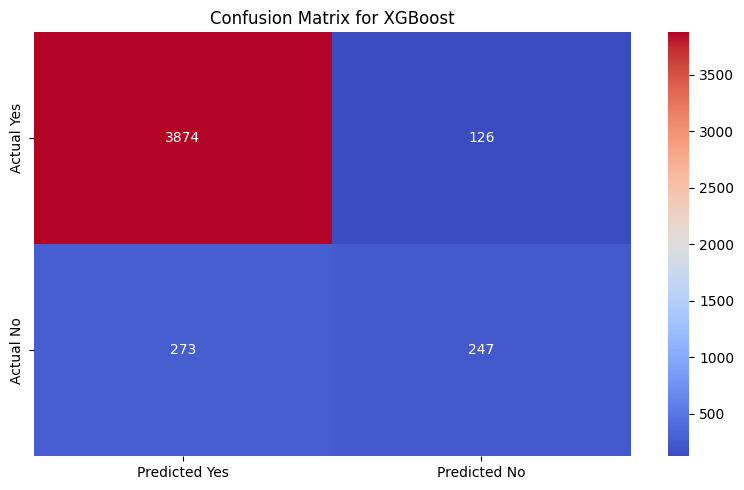

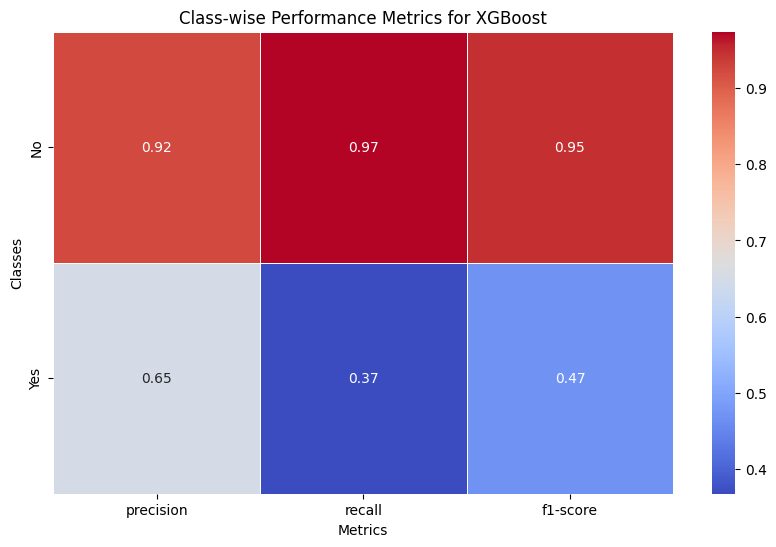

In [ ]:
# Classification report
xgb_classification_report = classification_report(y_test, xgb_y_pred)
print(xgb_classification_report)

# Confusion matrix with seaborn heatmap
xgb_conf_matrix = confusion_matrix(y_test, xgb_y_pred)
plt.figure(figsize=(8,5))
sns.heatmap(xgb_conf_matrix, annot=True, fmt="d", cmap='coolwarm', xticklabels=['Predicted Yes', 'Predicted No'], yticklabels=['Actual Yes', 'Actual No'])
plt.title('Confusion Matrix for XGBoost')
plt.tight_layout()
plt.savefig("XGBoost_confusion_matrix.png")

# Class-wise Performance Metrics
xgb_classification_report_2 = classification_report(y_test, RF_y_pred, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
class_metrics = {metric: [xgb_classification_report_2[class_name][metric] for class_name in ['0','1']] for metric in metrics}
plt.figure(figsize=(10, 6))
sns.heatmap(data=pd.DataFrame(class_metrics, index=['No','Yes']), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Class-wise Performance Metrics for XGBoost')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.savefig("XGBoost_performance_metrics.png")
plt.show()

###**ROC curve and precision-recall curve**

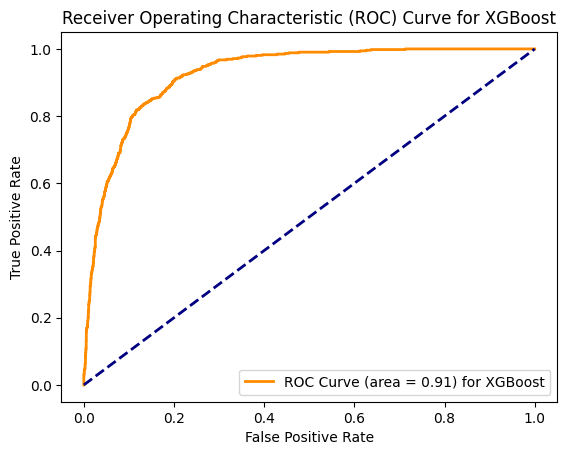

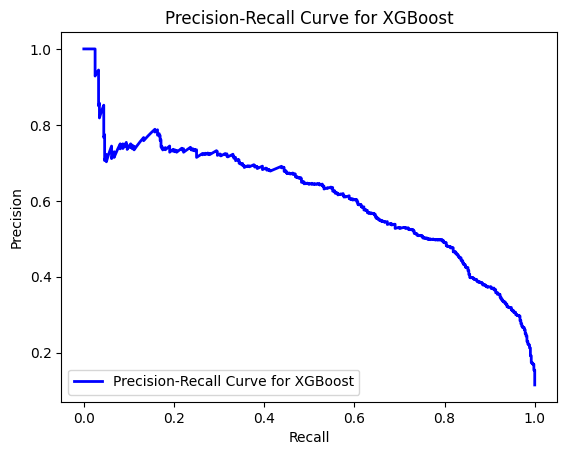

In [ ]:
xgb_y_scores = xgb_pipeline.predict_proba(X_test)[:, 1]

# ROC Curve
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, xgb_y_scores)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure()
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label='ROC Curve (area = %0.2f) for XGBoost' % roc_auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for XGBoost')
plt.legend(loc="lower right")
plt.savefig("XGBoost_roc_curve.png")

# Precision-Recall Curve
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, xgb_y_scores)
plt.figure()
plt.plot(recall_xgb, precision_xgb, color='blue', lw=2, label='Precision-Recall Curve for XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for XGBoost')
plt.legend(loc="lower left")
plt.savefig("XGBoost_precision_recall_curve.png")
plt.show()

# Compare 3 models

## ROC Curve

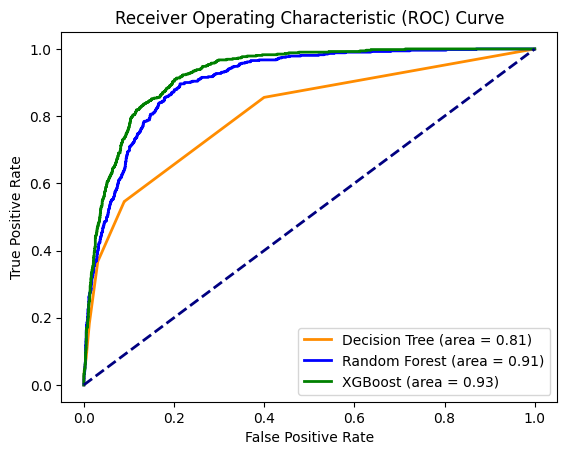

In [ ]:
# ROC Curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, DT_y_scores)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, RF_y_scores)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, thresholds_ = roc_curve(y_test, xgb_y_scores)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure()
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label='Decision Tree (area = %0.2f)' % roc_auc_dt)
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label='Random Forest (area = %0.2f)' % roc_auc_rf)
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label='XGBoost (area = %0.2f)' % roc_auc_xgb)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig("all_models_roc_curve.png")

## Precision-Recall Curve

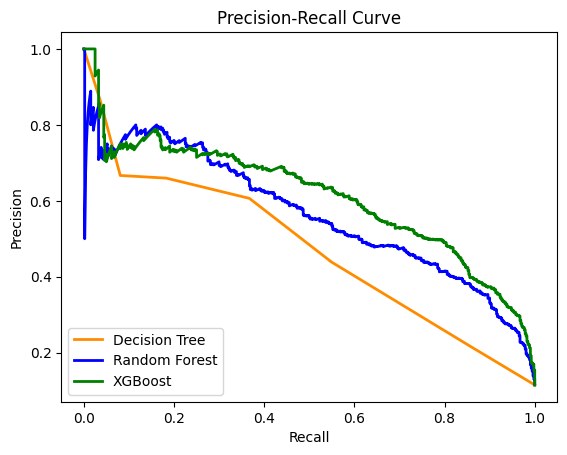

In [ ]:
# Precision-Recall Curve
precision_dt, recall_dt, thresholds_dt = precision_recall_curve(y_test, DT_y_scores)
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, RF_y_scores)
precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, xgb_y_scores)

plt.figure()
plt.plot(recall_dt, precision_dt, color='darkorange', lw=2, label='Decision Tree')
plt.plot(recall_rf, precision_rf, color='blue', lw=2, label='Random Forest')
plt.plot(recall_xgb, precision_xgb, color='green', lw=2, label='XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.savefig("all_models_precision_recall_curve.png")
plt.show()